<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/MLP_CLASSIFICA%C3%87%C3%83O_PADR%C3%95ES_AULA_PRATICA_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score # Biblioteca para separação de amostras para treino e teste, curva de ....
from sklearn.neural_network import MLPClassifier # Biblioteca para utilização do classificador MLP
from sklearn.preprocessing import MinMaxScaler, StandardScaler # Biblioteca utilizada para normalização de dados
from sklearn.model_selection import learning_curve # Biblioteca para avaliar um modelo por meio da curva de aprendizagem baseado no tamanho
from sklearn.pipeline import Pipeline # Biblioteca para organização de ações em sequência
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, precision_score, confusion_matrix, classification_report, f1_score, recall_score
from sklearn import metrics
import seaborn as sns # Biblioteca baseada no Matplotlib, que oferece uma interface de alto nível para criação de gráficos estatísticos
import matplotlib.pyplot as plt # Biblioteca para visualização dos dados e do erro
import numpy as np # Biblioteca de manipulação de arrays Numpy
from numpy import mean, std
import pandas as pd # Biblioteca para manipulação de dados, aqui para importação e manipulação inicial do dataset
from google.colab import drive # Biblioteca para interação do Colab com o Drive
drive.mount('/content/drive') # Monta o Google Drive na mesma conta do Google Colab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Caminho do dataset no Google Drive que será carregado em df
df = pd.read_csv("/content/drive/MyDrive/RNA_Datasets/irisMLP.csv")
display(df)
df = df.replace('Iris-setosa', 0)
df = df.replace('Iris-versicolor', 1)
df = df.replace('Iris-virginica', 2)
X = df.drop('variety', axis=1) # Exclusão da variável que estabelece a classe das entradas
y = df['variety'] # Inclusão da variável que estabelece a classe no vetor de saídas desejadas
print(y.shape)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


(150,)


/tmp/ipython-input-3009754740.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('Iris-virginica', 2)


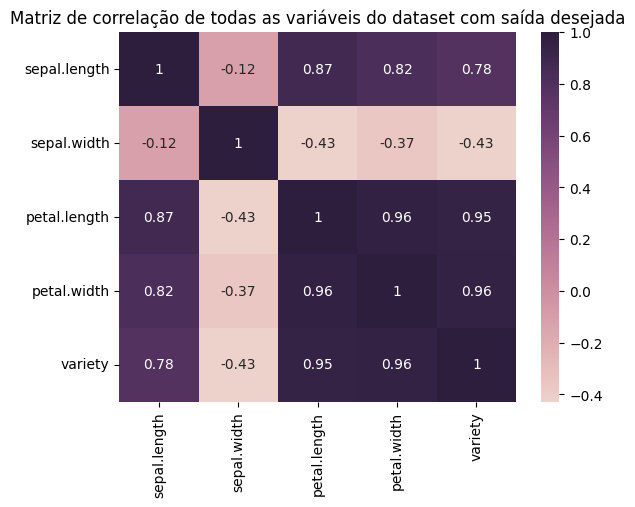

In [ ]:
# Gera um gráfico matricial para apresentar a correção entre as variáveis de entrada do dataset
ax = sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
ax.set_title('Matriz de correlação de todas as variáveis do dataset com saída desejada')
ax=ax

In [ ]:
# Padronização de dados
Xcv = X # Guardar o X original para usar nos testes de validação cruzada
scaler = MinMaxScaler().fit(X) # Cria o modelo para o ajuste
X = scaler.transform(X) # Aplica a padronização do dataset de treinamento baseado nos dados de treinamento
display(X)
# Separação do dataset em amostras para treino e teste, considerando 30% dos valores para teste, usa-se esse caso em detrimento da validação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)


array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(20), max_iter=10000, epsilon=1e-10, learning_rate='constant', learning_rate_init=0.001)
mlp.fit(X_train, y_train)
print("Número de saídas da RNA: ",mlp.n_outputs_)
print("Função de ativação da camada de saída da RNA: ", mlp.out_activation_)


Número de saídas da RNA:  3
Função de ativação da camada de saída da RNA:  softmax



MÉTRICAS DA CLASSIFICAÇÃO
Acurácia das amostras na classificação não apresentadas no treinamento:0.9333333333333333
Acurácia balanceada na classificação das amostras não apresentadas no treinamento:0.9500000000000001
Matriz de confusão das amostras não apresentadas no treinamento:
[[13  0  0]
 [ 0 17  3]
 [ 0  0 12]]

Relatório de classificação das amostras não apresentadas no treinamento:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
 Iris-virginica       1.00      0.85      0.92        20
Iris-versicolor       0.80      1.00      0.89        12

       accuracy                           0.93        45
      macro avg       0.93      0.95      0.94        45
   weighted avg       0.95      0.93      0.93        45



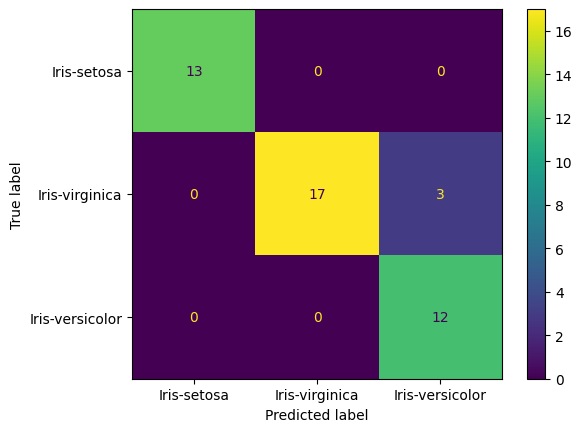

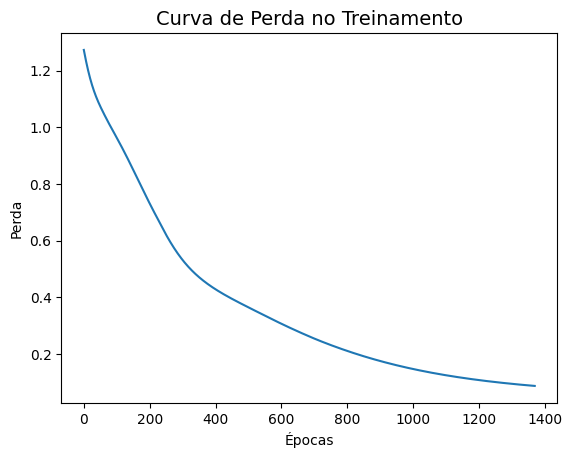


MÉTRICAS DO TREINAMENTO
Melhor loss de treinamento:  0.08699706853906913
ültimo valor do loss para convergência:  0.08699706853906913
Mean Absolute Error (MAE): 0.06666666666666667
Mean Squared Error (MSE): 0.06666666666666667


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
y_pred = mlp.predict(X_test)
print("\nMÉTRICAS DA CLASSIFICAÇÃO")
# Todas as métricas do sklearn.metrics para classificação https://scikit-learn.org/stable/modules/model.evaluation.html#classification-metrics
print(f"Acurácia das amostras na classificação não apresentadas no treinamento:{accuracy_score(y_test, y_pred)}")
print(f"Acurácia balanceada na classificação das amostras não apresentadas no treinamento:{balanced_accuracy_score(y_test, y_pred)}")
print(f"Matriz de confusão das amostras não apresentadas no treinamento:\n{confusion_matrix(y_test, y_pred)}")
print("")
relatorio = classification_report(y_test, y_pred, target_names=["Iris-setosa", "Iris-virginica", "Iris-versicolor"])
print("Relatório de classificação das amostras não apresentadas no treinamento:")
print(relatorio)

conf_matrix = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(conf_matrix, display_labels=["Iris-setosa", "Iris-virginica", "Iris-versicolor"])
cm_display.plot()
plt.show()
print("")

# Plotando o gráfico de erros no processo de treinamento
plt.plot(mlp.loss_curve_)
plt.title("Curva de Perda no Treinamento", fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.show()

print("\nMÉTRICAS DO TREINAMENTO")
print("Melhor loss de treinamento: ", mlp.best_loss_) # best_loss_ fornece o melhor valor de perda durante o treinamento
print("ültimo valor do loss para convergência: ", mlp.loss_) # loss_ fornece o último valor de perda do treinamento
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred)) # Variação de 0 ao infinito
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred)) # Variação de 0 ao infinito. Quanto menor, melhor
print('Root Mean Squared Error (RMSE):', metrics.mean_squared_error(y_test, y_pred, squared=False)) # Variação de 0 ao infinito. Quanto menor, melhor
print('Mean Absolute Percentage Error (MAPE):', metrics.mean_absolute_percentage_error(y_test, y_pred)) # Apresenta em percentage
print('R2: ', metrics.r2_score(y_test, y_pred)) # Apresenta o R2 Score - Representa o quanto o modelo está prevendo corretamente


In [ ]:

# criando uma sequência de operações com Pipeline
MLP_pipeline = Pipeline(steps=[
    ("Padronização", MinMaxScaler()),
    ("MLP", MLPClassifier(
        hidden_layer_sizes=(30,),
        random_state=12,
        max_iter=10000,
        epsilon=1e-10,
        learning_rate='constant',
        learning_rate_init=0.001
    ))
])

# Testando o dataset completo utilizando a validação cruzada
scores_cross_val = cross_val_score(MLP_pipeline, Xcv, y, cv=5)

print("Resultados da validação cruzada do conjunto completo de dados:")
print(scores_cross_val)
print("Média: ", mean(scores_cross_val))
print("Desvio Padrão: ", std(scores_cross_val))














Resultados da validação cruzada do conjunto completo de dados:
[0.96666667 1.         0.93333333 0.93333333 1.        ]
Média:  0.9666666666666668
Desvio Padrão:  0.029814239699997188


In [ ]:
from sklearn.model_selection import GridSearchCV
mlp = MLPClassifier()
param_grid = {
    'hidden_layer_sizes': [(10), (20), (30), (50)],
    'max_iter': [2000, 5000],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'learning_rate': ['constant', 'adaptive'],
}
grid = GridSearchCV(mlp, param_grid, n_jobs=-1, cv=5)
grid.fit(X,y)

GridSearchCV(cv=5, estimator=MLPClassifier(), n_jobs=-1,
             param_grid={'activation': ['tanh', 'relu'],
                         'hidden_layer_sizes': [10, 20, 30, 50],
                         'learning_rate': ['constant', 'adaptive'],
                         'max_iter': [2000, 5000], 'solver': ['sgd', 'adam']})

In [ ]:
print("Melhores valores dos parâmetros do grid: ", grid.best_params_)
print("Parâmetros mais relevantes para estimar: ", grid.best_estimator_)
print("Melhor acurácia: ", grid.best_score_)


Melhores valores dos parâmetros do grid:  {'activation': 'tanh', 'hidden_layer_sizes': 10, 'learning_rate': 'adaptive', 'max_iter': 2000, 'solver': 'adam'}
Parâmetros mais relevantes para estimar:  MLPClassifier(activation='tanh', hidden_layer_sizes=10,
              learning_rate='adaptive', max_iter=2000)
Melhor acurácia:  0.9733333333333334
